# Tutorial 0: Cruise Control

```{admonition} Download
:class: tip
{download}`Download this notebook <0_cruise_control.ipynb>`
```

## Overview
This is the introductory notebook for the dynamicalnodes pipeline. In it, we work through the cruise control example in the dynamicalnodes papein more detail. This notebook assumes you have already read the paper; if you haven't, we recommend you read the paper first.

We first reintroduce our car-with-cruise-control system from section [blank] in the paper and its discrete-time block diagram. Then we implement the discrete-time diagram via DynamicalSystem objects in order to simulate its behaviour. Next, we wrap DynamicalSystem objects in ROSNode objects and simulate ROS node communication. Finally, we autogenerate ROS files from our ROSNode objects, write a launch file, and spin up a live ROS graph of our car-with-cruise-control system.

## Feedback: A Car with Cruise Control
Recall that the discrete-time diagram for a general feedback system is of the following form:

For our car-with-cruise-control system, each block will be implemented as follows:

- reference generator = cruise control button​

- controller = PID control

- plant = car + speedometer

- observer = Kalman filter

The car velocity will track a sinusoidal reference signal. A Kalman filter estimates the car state from noisy velocity measurements
and feeds the estimate back to the PID controller.

## Implementing the discrete-time blocks

Each block above can be cast as a [`DynamicalSystem(f=..., h=...)`](https://nehalsinghmangat.github.io/dynamicalnodes/api/dynamical_system.html) object, where:

- `f(x_k, ...)` → `x_{k+1}`
- `h(x_k, ...)` → `y_k`

The associated (f,h)-functions for each block are defined below and then encapsulated in a DynamicalSystem object.

In [1]:
import numpy as np
from dynamicalnodes import DynamicalSystem

### Reference Signal

Stateless sinusoid: $r_k = A \sin(\omega\, t_k)$.
Computed directly from $t_k$ — no internal state, so a dynamics function $f$ is unnecessary.

In [2]:
def ref_h(tk, A, omega):
    return A * np.sin(omega * tk)


ref_block = DynamicalSystem(h=ref_h)

### PID Controller

State: $(e_{k-1},\, \int e)$ — previous error and accumulated integral.

$$u_k = K_P e_k + K_I \sum e_k \Delta t + K_D \frac{e_k - e_{k-1}}{\Delta t}$$

In [3]:
def pid_f(ck, rk, xhatk, KP, KI, KD, dt):
    """Update PID state: returns (prev_error, integral)."""
    e_prev, e_int = ck
    ek = rk - xhatk
    return (ek, e_int + ek * dt)


def pid_h(ck, rk, xhatk, KP, KI, KD, dt):
    """Compute control output from current PID state."""
    e_prev, e_int = ck
    ek = rk - xhatk
    e_der = (ek - e_prev) / dt
    return KP * ek + KI * e_int + KD * e_der


pid_block = DynamicalSystem(f=pid_f, h=pid_h)

### Car Plant

State: $p_k = [\text{position},\; \text{velocity}]^\top$.

$$
\begin{bmatrix} p_{k+1} \\ v_{k+1} \end{bmatrix}
=
\begin{bmatrix} p_k + \Delta t\, v_k \\ v_k + \Delta t\left(-\tfrac{b}{m} v_k + \tfrac{u_k}{m}\right) \end{bmatrix}
$$

The measurement $y_k = v_k$ is the current velocity (we will simulate noise in our simulation later).

In [4]:
def plant_f(pk, uk, m, b, dt):
    p, v = pk
    return np.array([p + dt * v, v + dt * (-b / m * v + uk / m)])


def plant_h(pk):
    return pk[1]  # velocity


plant_block = DynamicalSystem(f=plant_f, h=plant_h)

### Kalman Filter

State: $z_k = (\hat{x}_k,\, P_k)$ — state estimate and covariance.

**Predict:**
$$\hat{x}_{k|k-1} = F_k \hat{x}_{k-1} + B_k u_k, \qquad P_{k|k-1} = F_k P_{k-1} F_k^\top + Q_k$$

**Update:**
$$K_k = P_{k|k-1} H_k^\top S_k^{-1}, \quad
\hat{x}_k = \hat{x}_{k|k-1} + K_k(y_k - H_k \hat{x}_{k|k-1}), \quad
P_k = (I - K_k H_k) P_{k|k-1}$$

In [5]:
def kf_f(zk, uk, yk, Fk, Bk, Hk, Qk, Rk):
    """Discrete Kalman predict-update. Returns updated (x_est, P)."""
    x, P = zk
    # Predict
    x_pred = Fk @ x + Bk * uk
    P_pred = Fk @ P @ Fk.T + Qk
    # Update
    yk = np.atleast_1d(yk)
    y_res = yk - Hk @ x_pred
    S = Hk @ P_pred @ Hk.T + Rk
    K = P_pred @ Hk.T @ np.linalg.inv(S)
    x_upd = x_pred + K @ y_res
    P_upd = (np.eye(len(x)) - K @ Hk) @ P_pred
    return (x_upd, P_upd)


def kf_h(zk):
    return zk[0][1]  # velocity estimate


kf_block = DynamicalSystem(f=kf_f, h=kf_h)

## Simulate the discrete-time diagram using DynamicalSystem

In [6]:
# Simulation Time
dt = 1.0
sim_time = np.arange(0, 60, dt)

# ── Parameters ──────────────────────────────────────────────
# Reference
A_ref = 30.0
omega_ref = np.pi / 60.0  # rad/s — full period 120 s

# PID
KP, KI, KD = 500.0, 30.0, 10.0

# Car
m, b = 1500.0, 50.0

# Kalman filter
Fk = np.array([[1.0, dt], [0.0, 1.0 - (b / m) * dt]])
Bk = np.array([0.0, dt / m])  # control-input vector
Hk = np.array([[0.0, 1.0]])  # observe velocity
Qk = np.array([[0.05, 0.0], [0.0, 0.1]])
Rk = np.array([[2.0]])

# Measurement noise std for synthetic observations
v_noise_std = np.sqrt(Rk[0, 0])

# ── Initial States ──────────────────────────────────────────────
ck = (0.0, 0.0)  # PID: (e_prev, e_int)
pk = np.array([0.0, 0.0])  # plant: [position, velocity]
zk = (np.array([0.0, 0.0]), np.eye(2))  # KF: (x_est, P)

# ── Initial Inputs ──────────────────────────────────────────────
v_est = zk[0][1]  # required for first step of our controller

# ── Simulation Memory  ──────────────────────────────────────────────
ref_out, ctrl_out, plant_out, kf_out = [], [], [], []

for tk in sim_time:

    # ── Reference ──────────────────────────────────────────────
    rk = ref_block.step(tk=tk, A=A_ref, omega=omega_ref)

    # ── PID (uses KF velocity estimate) ─────────────────
    ck_next, uk = pid_block.step(ck=ck, rk=rk, xhatk=v_est, KP=KP, KI=KI, KD=KD, dt=dt)

    # ── Car ──────────────────────────────────────────────────
    pk_next, vk = plant_block.step(pk=pk, uk=uk, m=m, b=b, dt=dt)

    yk_noisy = vk + np.random.normal(0.0, v_noise_std)  # add noise

    # ── Kalman Filter ──────────────────────────────────────────
    zk_next, v_est = kf_block.step(
        zk=zk, uk=uk, yk=np.array([yk_noisy]), Fk=Fk, Bk=Bk, Hk=Hk, Qk=Qk, Rk=Rk
    )

    ref_out.append(rk)
    ctrl_out.append(uk)
    plant_out.append(vk)
    kf_out.append(v_est)

    # ── set n + 1 state ────────────────────────────────────────────────
    ck, pk, zk = ck_next, pk_next, zk_next

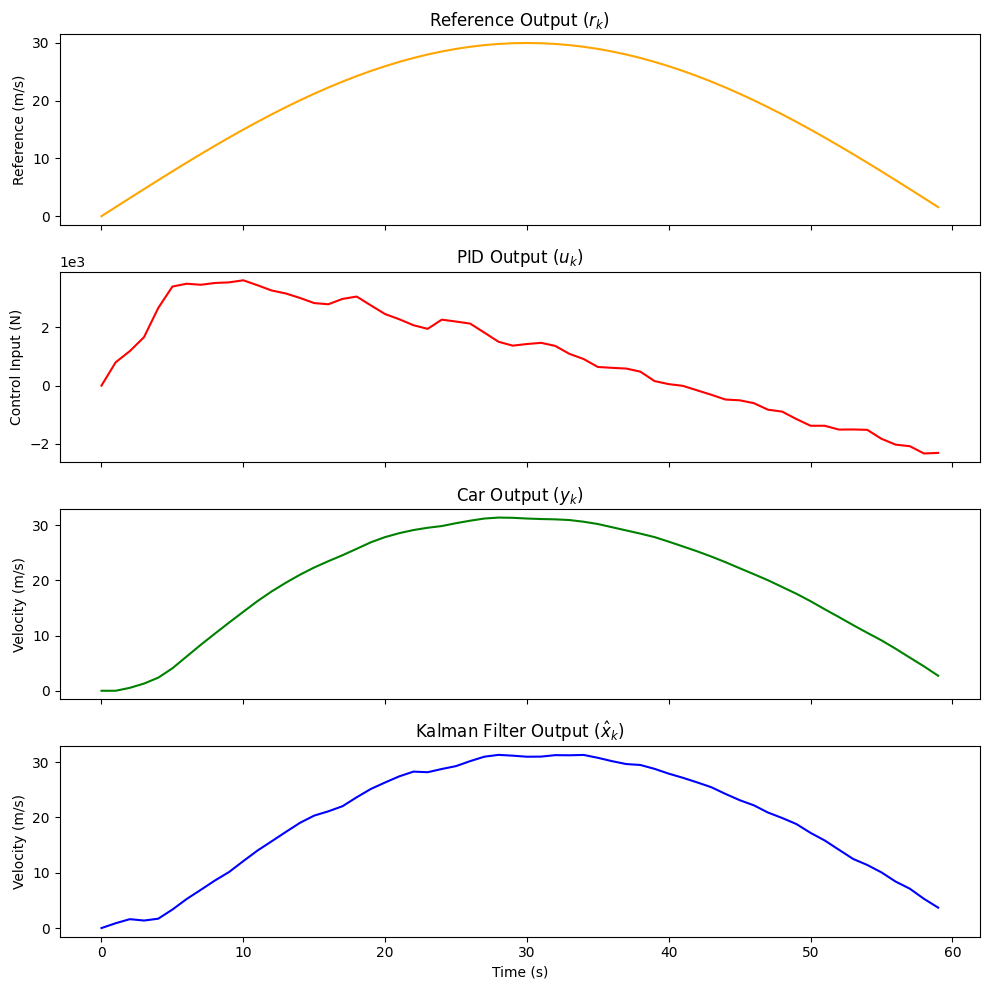

In [7]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(10, 10))

axs[0].plot(sim_time, ref_out, color="orange")
axs[0].set_ylabel("Reference (m/s)")
axs[0].set_title("Reference Output ($r_k$)")

axs[1].plot(sim_time, ctrl_out, color="red")
axs[1].set_ylabel("Control Input (N)")
axs[1].set_title("PID Output ($u_k$)")
axs[1].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

axs[2].plot(sim_time, plant_out, color="green")
axs[2].set_ylabel("Velocity (m/s)")
axs[2].set_title("Car Output ($y_k$)")

axs[3].plot(sim_time, kf_out, color="blue")
axs[3].set_ylabel("Velocity (m/s)")
axs[3].set_xlabel("Time (s)")
axs[3].set_title("Kalman Filter Output ($\\hat{x}_k$)")

plt.tight_layout()
plt.savefig("car_cruise_control_figure.pdf", format="pdf", bbox_inches="tight")
plt.show()

## ROSNode Simulation — Converter Verification

This section re-runs the same cruise-control loop through the [`ROSNode`](https://nehalsinghmangat.github.io/dynamicalnodes/api/rosnode.html) layer.
The purpose is not to simulate ROS timing behaviour, but to confirm that the
ros2py / py2ros message converters and the `DynamicalSystem` wiring are correct
before generating the deployment nodes.

In [8]:
from dynamicalnodes import ROSNode
from dynamicalnodes.ros2py_py2ros import ros2py_float64, py2ros_float64
from std_msgs.msg import Float64

ref_node = ROSNode(
    dynamical_system=ref_block,
    publishes_to=[{"topic": "/rk", "msg_type": Float64, "py2ros": py2ros_float64}],
    timer_hz=10,
)

pid_node = ROSNode(
    dynamical_system=pid_block,
    subscribes_to=[
        {"topic": "/rk", "msg_type": Float64, "arg": "rk", "ros2py": ros2py_float64},
        {
            "topic": "/xhatk",
            "msg_type": Float64,
            "arg": "xhatk",
            "ros2py": ros2py_float64,
        },
    ],
    publishes_to=[{"topic": "/uk", "msg_type": Float64, "py2ros": py2ros_float64}],
    sync_mode="all",
    state_name="ck",
)

plant_node = ROSNode(
    dynamical_system=plant_block,
    subscribes_to=[
        {"topic": "/uk", "msg_type": Float64, "arg": "uk", "ros2py": ros2py_float64},
    ],
    publishes_to=[{"topic": "/yk", "msg_type": Float64, "py2ros": py2ros_float64}],
    state_name="pk",
)

kf_node = ROSNode(
    dynamical_system=kf_block,
    subscribes_to=[
        {"topic": "/uk", "msg_type": Float64, "arg": "uk", "ros2py": ros2py_float64},
        {"topic": "/yk", "msg_type": Float64, "arg": "yk", "ros2py": ros2py_float64},
    ],
    publishes_to=[{"topic": "/xhatk", "msg_type": Float64, "py2ros": py2ros_float64}],
    sync_mode="all",
    state_name="zk",
)
# %%[markdown]
# Run the simulation

In [9]:
# Initial States
pid_node._state = (0.0, 0.0)  # PID: (e_prev, e_int)
plant_node._state = np.array([0.0, 0.0])  # plant: [position, velocity]
kf_node._state = (np.zeros(2), np.eye(2))  # KF: (x_est, P)

# Initial Inputs
xhatk_ros = Float64(data=0.0)  # bootstrap before first KF output

ref_node_out, ctrl_node_out, plant_node_out, kf_node_out = [], [], [], []

for tk in sim_time:

    # ── Reference ──────────────────────────────────────────────
    rk_ros = ref_node.step(tk=tk, A=A_ref, omega=omega_ref)

    # ── PID ────────────────────────────────────────────────────
    uk_ros = pid_node.step(rk=rk_ros, xhatk=xhatk_ros, KP=KP, KI=KI, KD=KD, dt=dt)

    # ── Plant ──────────────────────────────────────────────────
    yk_ros = plant_node.step(uk=uk_ros, m=m, b=b, dt=dt)

    yk_meas_ros = Float64(
        data=yk_ros.data + np.random.normal(0.0, v_noise_std)
    )  # add noise

    # ── Kalman Filter ──────────────────────────────────────────
    xhatk_ros = kf_node.step(
        uk=uk_ros, yk=yk_meas_ros, Fk=Fk, Bk=Bk, Hk=Hk, Qk=Qk, Rk=Rk
    )

    ref_node_out.append(rk_ros.data)
    ctrl_node_out.append(uk_ros.data)
    plant_node_out.append(yk_ros.data)
    kf_node_out.append(xhatk_ros.data)

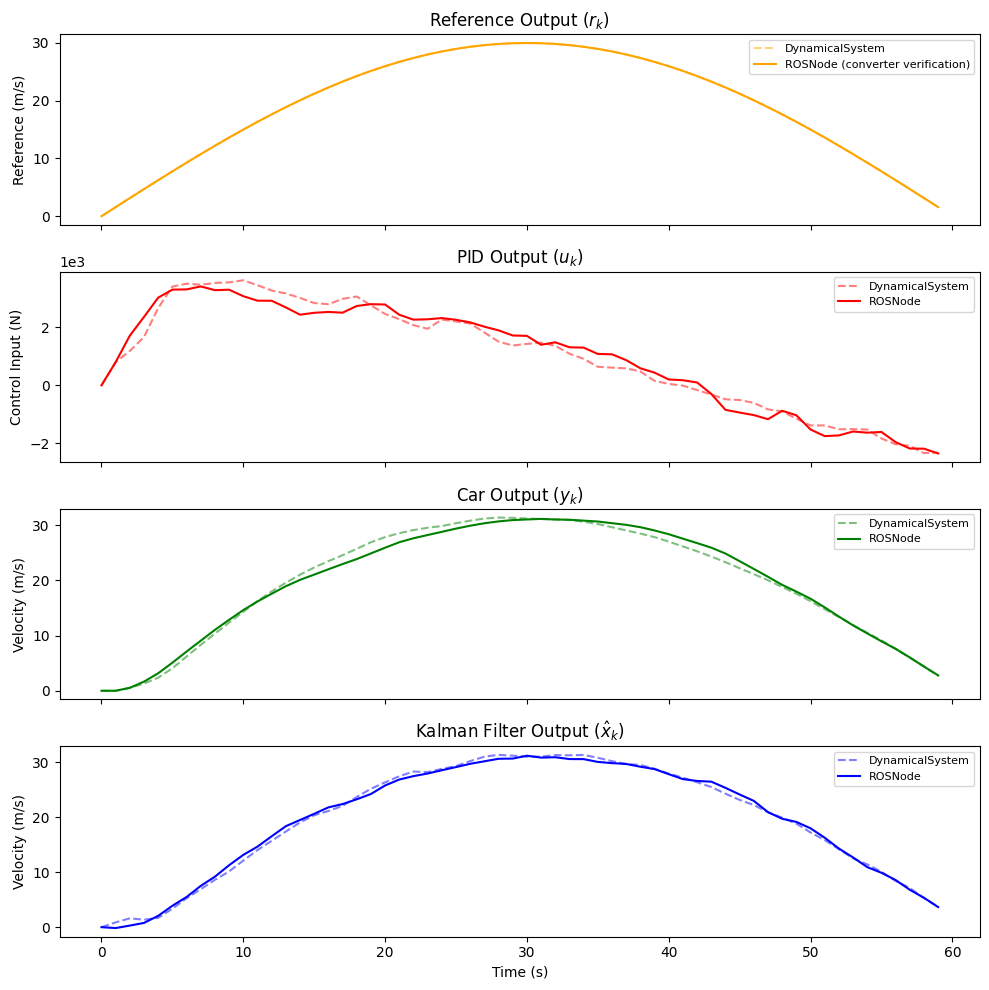

In [10]:
fig3, axs3 = plt.subplots(4, 1, sharex=True, figsize=(10, 10))

axs3[0].plot(
    sim_time,
    ref_out,
    color="orange",
    linestyle="--",
    alpha=0.5,
    label="DynamicalSystem",
)
axs3[0].plot(
    sim_time, ref_node_out, color="orange", label="ROSNode (converter verification)"
)
axs3[0].set_ylabel("Reference (m/s)")
axs3[0].set_title("Reference Output ($r_k$)")
axs3[0].legend(fontsize=8)

axs3[1].plot(
    sim_time, ctrl_out, color="red", linestyle="--", alpha=0.5, label="DynamicalSystem"
)
axs3[1].plot(sim_time, ctrl_node_out, color="red", label="ROSNode")
axs3[1].set_ylabel("Control Input (N)")
axs3[1].set_title("PID Output ($u_k$)")
axs3[1].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
axs3[1].legend(fontsize=8)

axs3[2].plot(
    sim_time,
    plant_out,
    color="green",
    linestyle="--",
    alpha=0.5,
    label="DynamicalSystem",
)
axs3[2].plot(sim_time, plant_node_out, color="green", label="ROSNode")
axs3[2].set_ylabel("Velocity (m/s)")
axs3[2].set_title("Car Output ($y_k$)")
axs3[2].legend(fontsize=8)

axs3[3].plot(
    sim_time, kf_out, color="blue", linestyle="--", alpha=0.5, label="DynamicalSystem"
)
axs3[3].plot(sim_time, kf_node_out, color="blue", label="ROSNode")
axs3[3].set_ylabel("Velocity (m/s)")
axs3[3].set_xlabel("Time (s)")
axs3[3].set_title("Kalman Filter Output ($\\hat{x}_k$)")
axs3[3].legend(fontsize=8)

plt.tight_layout()
plt.savefig("cruise_control_async.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Deploying to ROS2

`write_ROSNode_to_rclpy()` generates a self-contained rclpy Python file for each node —
a native `Node` subclass with explicit QoS profiles, subscription buffers,
callbacks, publishers, and executor setup. No dynamicalnodes runtime is needed
on the deployment machine beyond `DynamicalSystem`.

Pass `node_name` here (not in the constructor) since it is a deployment detail,
not a simulation one.

Parameters fall into three categories:

| Parameter | Purpose | Example |
|---|---|---|
| `static_params` | Baked in at generation time — never change | `dt`, `m`, `b`, model matrices |
| `dynamic_params` | Declared on the ROS2 parameter server — tunable at runtime via `ros2 param set` | `KP`, `KI`, `KD` |
| `initial_inputs` | Cold-start value for a subscribed input — used only until the first message arrives, then the subscription takes over; goes to `None` (not this value) if the publisher later stops | `xhatk=0.0` breaks the PID→KF startup ordering dependency |

In [11]:
import os

os.makedirs("./ros_nodes", exist_ok=True)

# Deployment dt matches the reference node's publish rate.
# The simulation uses dt=1.0 s; the ROS2 nodes fire at 10 Hz → dt=0.1 s.
ref_hz = 10  # must match timer_hz on ref_node
dt_ros = 1.0 / ref_hz

# Recompute KF matrices for the deployment timestep.
Fk_ros = np.array([[1.0, dt_ros], [0.0, 1.0 - (b / m) * dt_ros]])
Bk_ros = np.array([0.0, dt_ros / m])
Qk_ros = Qk * (dt_ros / dt)  # process noise scales linearly with dt

ref_node.write_ROSNode_to_rclpy(
    "./ros_nodes/reference_node.py",
    node_name="reference",
    static_params={"A": A_ref, "omega": omega_ref},
)
pid_node.write_ROSNode_to_rclpy(
    "./ros_nodes/controller_node.py",
    node_name="controller",
    initial_state=(0.0, 0.0),
    static_params={"dt": dt_ros},
    dynamic_params={"KP": KP, "KI": KI, "KD": KD},
    initial_inputs={"xhatk": 0.0},
)
plant_node.write_ROSNode_to_rclpy(
    "./ros_nodes/plant_node.py",
    node_name="plant",
    initial_state=np.array([0.0, 0.0]),
    static_params={"m": m, "b": b, "dt": dt_ros},
    pub_noise={"/yk": v_noise_std},
)
kf_node.write_ROSNode_to_rclpy(
    "./ros_nodes/kalman_node.py",
    node_name="kalman",
    initial_state=(np.zeros(2), np.eye(2)),
    static_params={"Fk": Fk_ros, "Bk": Bk_ros, "Hk": Hk, "Qk": Qk_ros, "Rk": Rk},
)
print("Written: reference_node.py  controller_node.py  plant_node.py  kalman_node.py")

Written: reference_node.py  controller_node.py  plant_node.py  kalman_node.py


## Write the launch file

Copy and paste the contents below into a launch file (recommended name: cruise_control.launch.py).

In [12]:
#!/usr/bin/env python3
"""
Launch all four cruise-control nodes as separate processes.

Topic graph:
    reference  →  /rk    →  controller
    controller →  /uk    →  plant, kalman
    plant      →  /yk    →  kalman
    kalman     →  /xhatk →  controller

Startup ordering:
    Nodes may start in any order. The controller's initial_inputs={"xhatk": 0.0}
    provides a cold-start value for /xhatk so it does not stall waiting for the
    Kalman filter to produce its first estimate.

Run:
    ros2 launch ros_nodes/cruise_control.launch.py

Tune PID gains at runtime (no restart required):
    ros2 param set /controller KP 600.0
    ros2 param set /controller KI 25.0
    ros2 param set /controller KD 15.0

Inspect:
    ros2 topic echo /uk
    rqt_graph
"""

import os
from launch import LaunchDescription
from launch.actions import ExecuteProcess, TimerAction


def generate_launch_description() -> LaunchDescription:
    here = os.path.dirname(os.path.abspath(__file__))

    def py_node(script: str) -> ExecuteProcess:
        return ExecuteProcess(
            cmd=["python3", os.path.join(here, script)],
            output="screen",
        )

    return LaunchDescription(
        [
            py_node("reference_node.py"),
            py_node("controller_node.py"),
            py_node("plant_node.py"),
            py_node("kalman_node.py"),
            # Delay rqt_graph so all nodes have registered before it opens.
            TimerAction(
                period=2.0,
                actions=[ExecuteProcess(cmd=["rqt_graph"])],
            ),
        ]
    )

## Running the Live ROS2 Graph

**Terminal 1 — launch all nodes:**

```bash
ros2 launch cruise_control.launch.py
```

All four nodes start and stream their output to the terminal. After 2 seconds,
`rqt_graph` opens automatically showing the live topic graph — if you see all
four nodes connected by the correct topics (`/rk`, `/uk`, `/yk`, `/xhatk`),
everything is working.

**Terminal 2 — visualize with PlotJuggler:**

Open a second terminal into the same container:

```bash
sudo docker exec -it $(sudo docker ps -q) bash
```

Then launch PlotJuggler:

```bash
ros2 run plotjuggler plotjuggler
```

In PlotJuggler: click **Streaming → ROS2 Topic Subscriber**, select the topics
you want (`/rk`, `/uk`, `/yk`, `/xhatk`), click **Start**, then drag individual
fields from the left panel onto the plot area to watch them live.